# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/data.csv')
df.head()



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

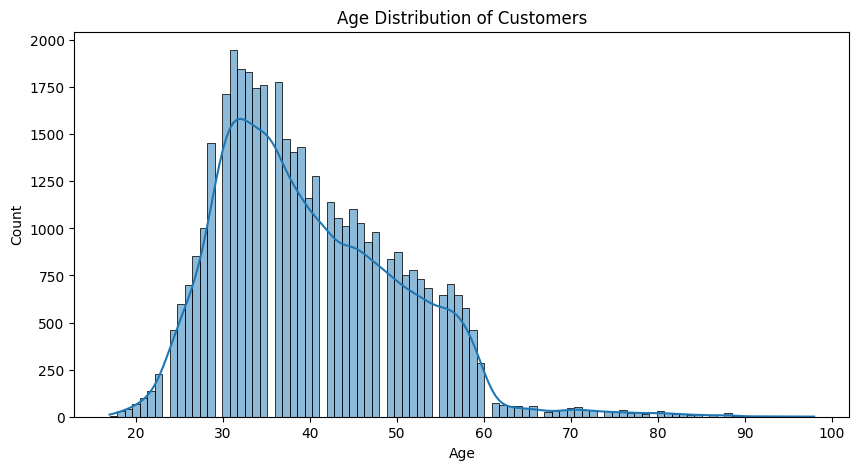

In [ ]:
# Age distribution
plt.figure(figsize=(10,5))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

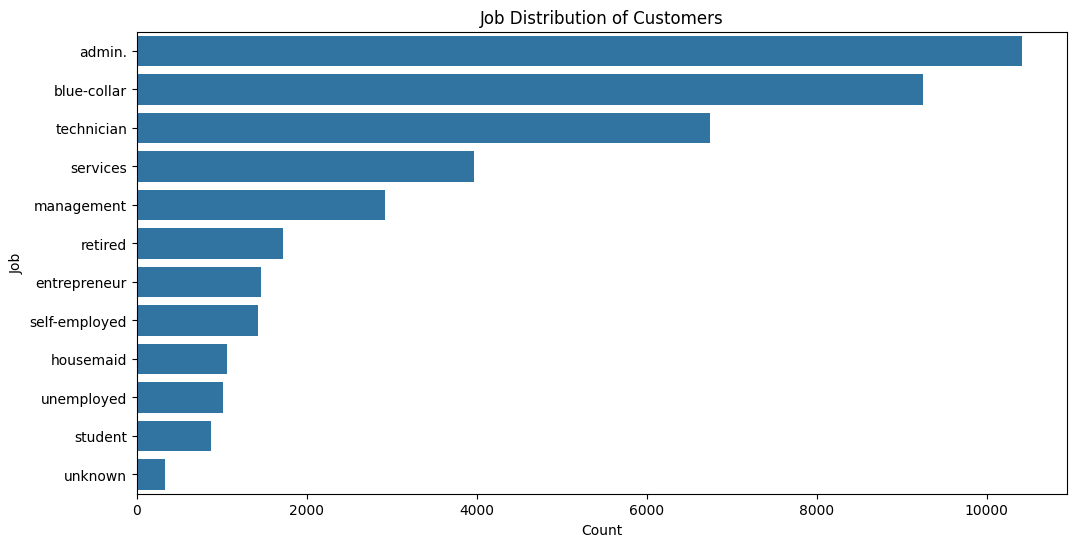

In [ ]:
# Job distribution
plt.figure(figsize=(12,6))
sns.countplot(y=df['job'], order=df['job'].value_counts().index)
plt.title('Job Distribution of Customers')
plt.xlabel('Count')
plt.ylabel('Job')
plt.show()

## Balance & Deposit Trends

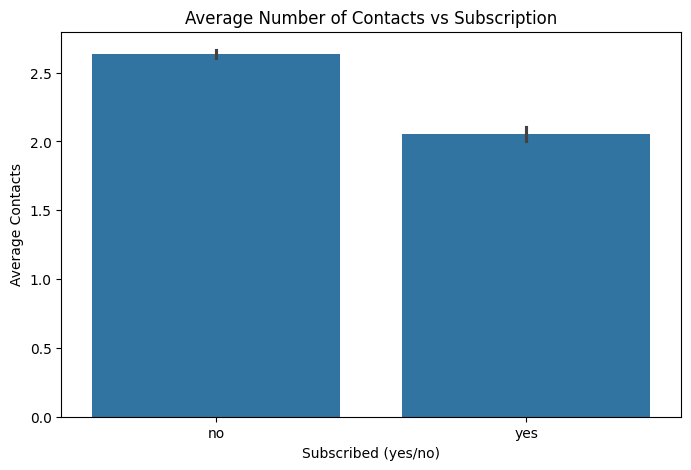

In [ ]:
# Average number of contacts vs subscription

plt.figure(figsize=(8,5))
sns.barplot(x='y', y='campaign', data=df)
plt.title('Average Number of Contacts vs Subscription')
plt.xlabel('Subscribed (yes/no)')
plt.ylabel('Average Contacts')
plt.show()


## Campaign Effectiveness

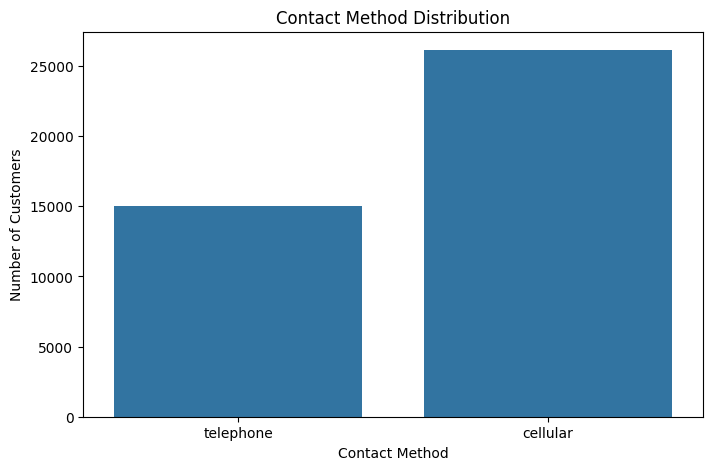

In [ ]:
# Contact method analysis
plt.figure(figsize=(8,5))
sns.countplot(x='contact', data=df)
plt.title('Contact Method Distribution')
plt.xlabel('Contact Method')
plt.ylabel('Number of Customers')
plt.show()

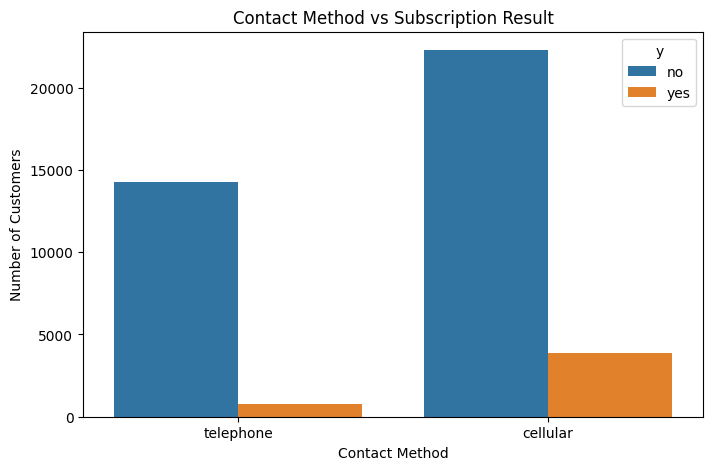

In [ ]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(8,5))
sns.countplot(x='contact', hue='y', data=df)
plt.title('Contact Method vs Subscription Result')
plt.xlabel('Contact Method')
plt.ylabel('Number of Customers')
plt.show()

## Correlation Heatmap

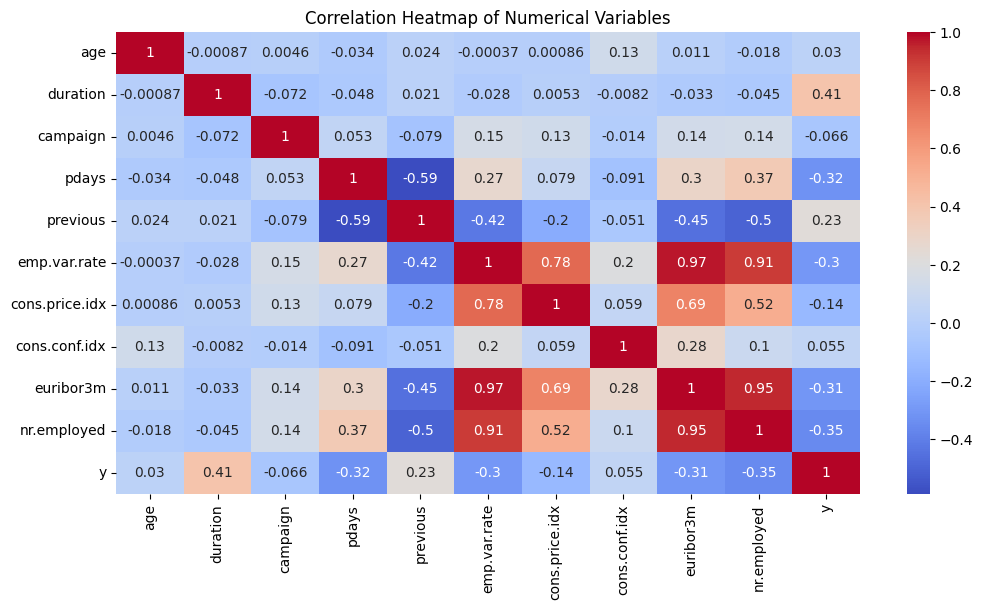

In [ ]:
# Correlation of numerical variables

#copy of dataset
df_corr = df.copy()

#convert to numeric
df_corr['y'] = df_corr['y'].map({'no': 0, 'yes': 1})

#select only numeric numbers
numeric_df = df_corr.select_dtypes(include=['int64', 'float64'])

#heatmap
plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

## Predictive Modeling (Logistic Regression)

In [ ]:


# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

#encode all categorical columns
label = LabelEncoder()
for column in df_model.select_dtypes(include=['object']).columns:
    df_model[column] = label.fit_transform(df_model[column])

df_model.head()

# Predictions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df_model.drop('y', axis=1)
y = df_model['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9104151493080845

Confusion Matrix:
 [[7111  192]
 [ 546  389]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.51       935

    accuracy                           0.91      8238
   macro avg       0.80      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Feature importance
importance = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance


,Feature,Importance
16,cons.price.idx,0.520580
14,poutcome,0.282525
2,marital,0.092420
3,education,0.058920
9,day_of_week,0.048401
17,cons.conf.idx,0.045087
1,job,0.011472
10,duration,0.004552
0,age,0.004353
12,pdays,-0.001391


## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.